In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
df = pd.read_csv('/Users/bigkems/Desktop/Projets Perso/Formation AI-engineer/Projet Fitness_market/data/clean_gym_data.csv')
df.head()

print(df.head())

# On devra transformer les donnee literaire en numerique: region et country
# Variable temporelle : year
# Le reste sont des variables numerique

In [ ]:
# Verifier les valeurs manquantes et doublons

df.isnull().sum()

# seul la derniere commande est affiché

In [32]:
# On trouve la variable cible
df["gym_memberships"].describe()
df["gym_memberships"].skew()

# skew retourne une valeur de 7, donc la distribution est extremement desequilibre. 

nan

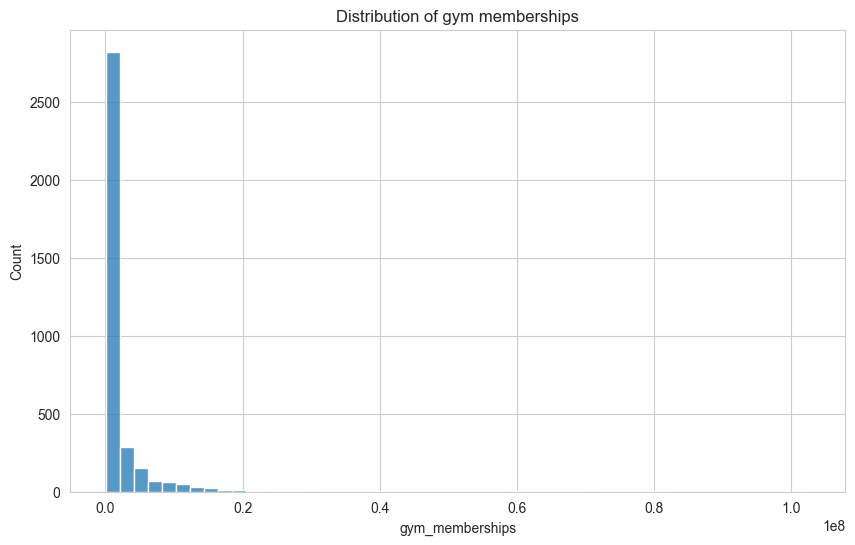

In [48]:
# Visualisation
sns.histplot(df["gym_memberships"], bins=50)
plt.title("Distribution of gym memberships")
plt.show()

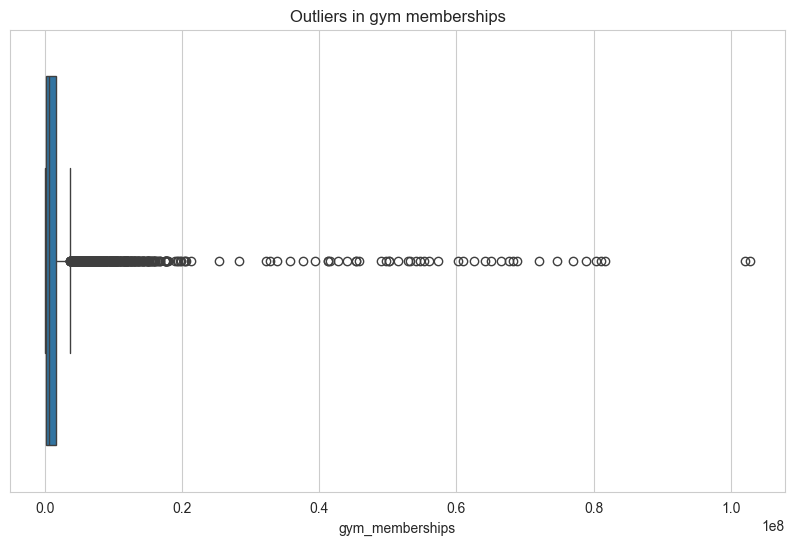

In [ ]:
# Visualisation
sns.boxplot(x=df["gym_memberships"])
plt.title("Outliers in gym memberships")
plt.show()

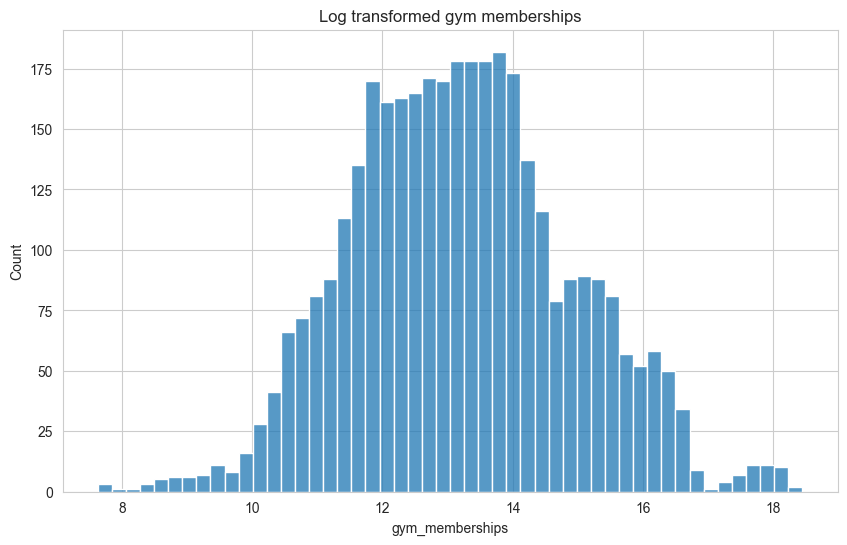

In [41]:
# Transformation Log
sns.histplot(np.log1p(df["gym_memberships"]), bins=50)
plt.title("Log transformed gym memberships")
plt.show()

In [49]:
# On crée la colonne transformée en Log pour stabiliser le modèle
df['gym_memberships_log'] = np.log1p(df['gym_memberships'])


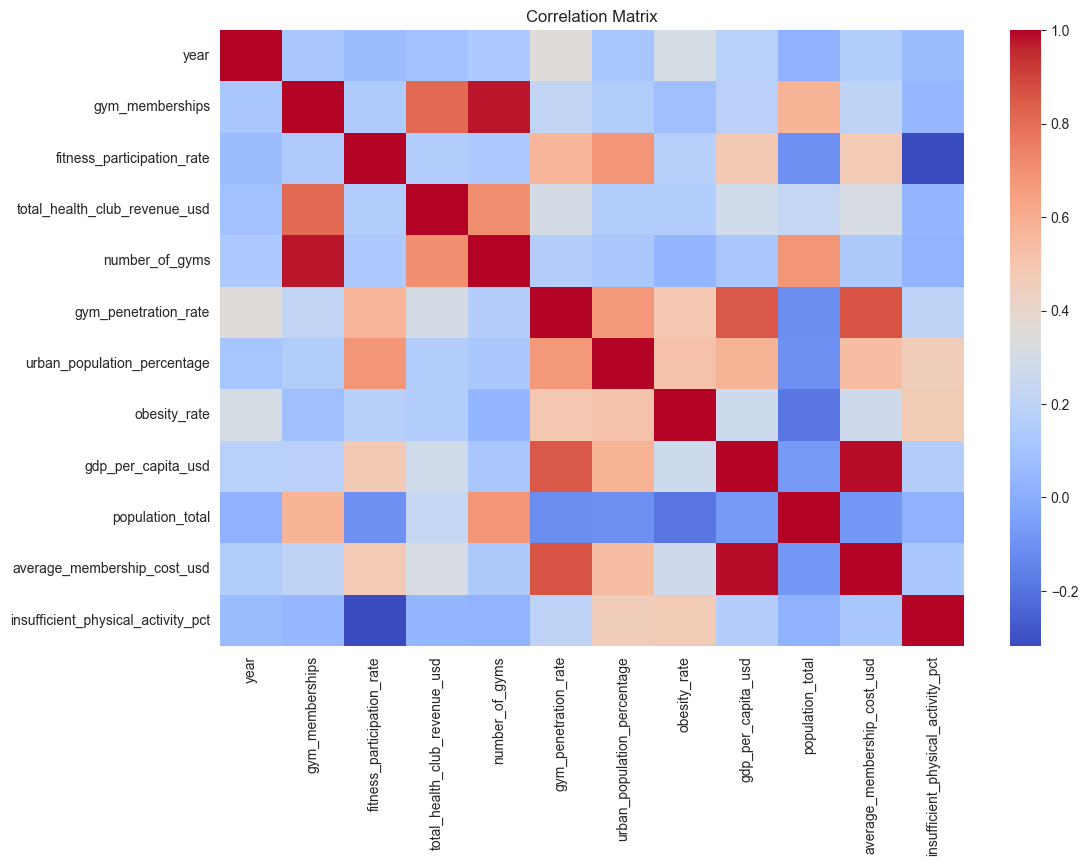

In [42]:
# Evaluer la correlation pour trouver les variables influentes
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Matrix")
plt.show()

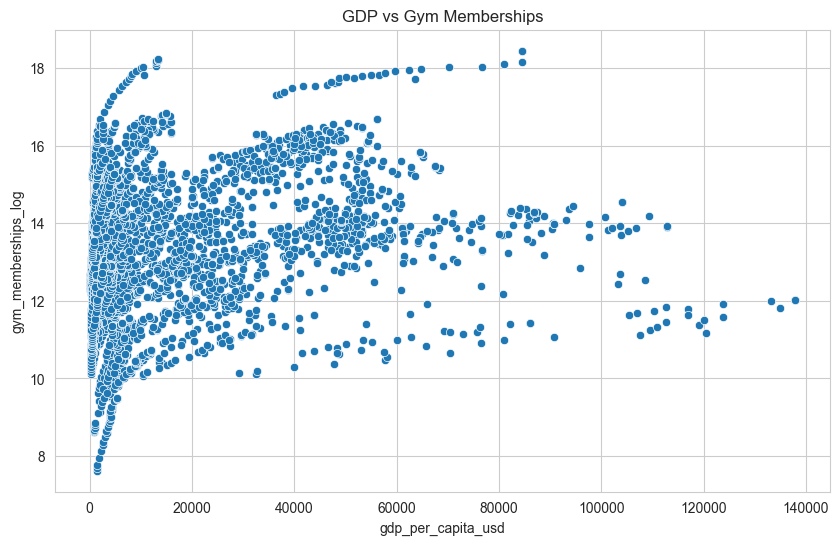

In [50]:
sns.scatterplot(data=df, x="gdp_per_capita_usd", y="gym_memberships_log")
plt.title("GDP vs Gym Memberships")
plt.show()

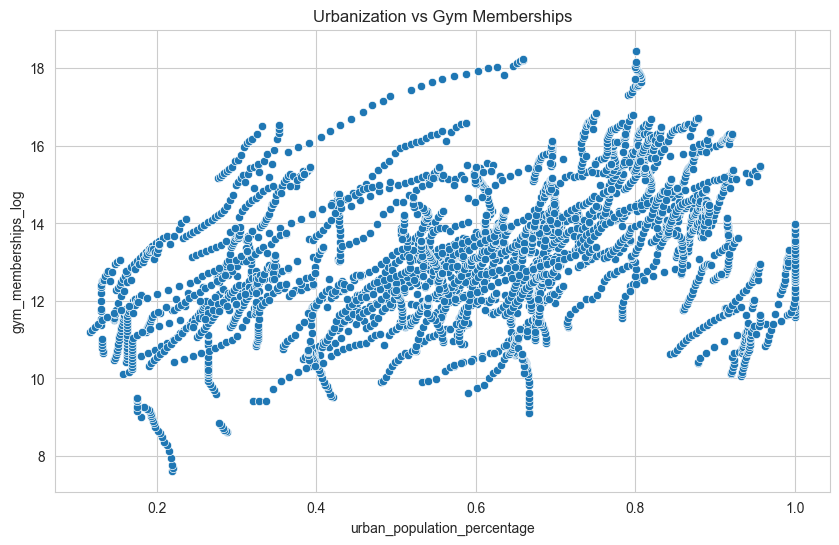

In [51]:
sns.scatterplot(data=df, x="urban_population_percentage", y="gym_memberships_log")
plt.title("Urbanization vs Gym Memberships")
plt.show()

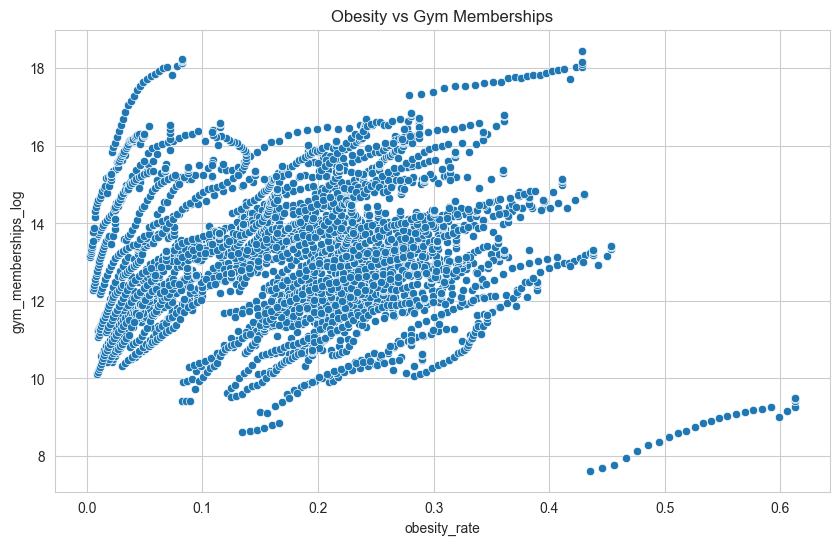

In [52]:
sns.scatterplot(data=df, x="obesity_rate", y="gym_memberships_log")
plt.title("Obesity vs Gym Memberships")
plt.show()

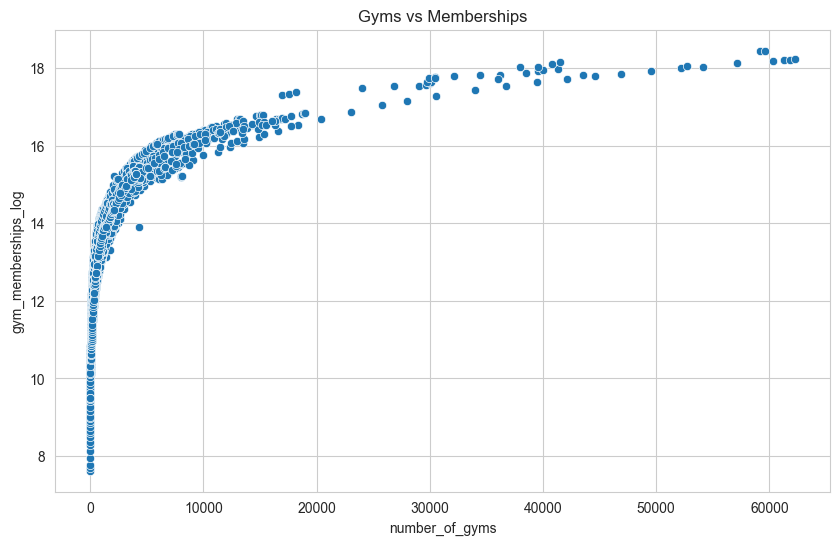

In [53]:
sns.scatterplot(data=df, x="number_of_gyms", y="gym_memberships_log")
plt.title("Gyms vs Memberships")
plt.show()

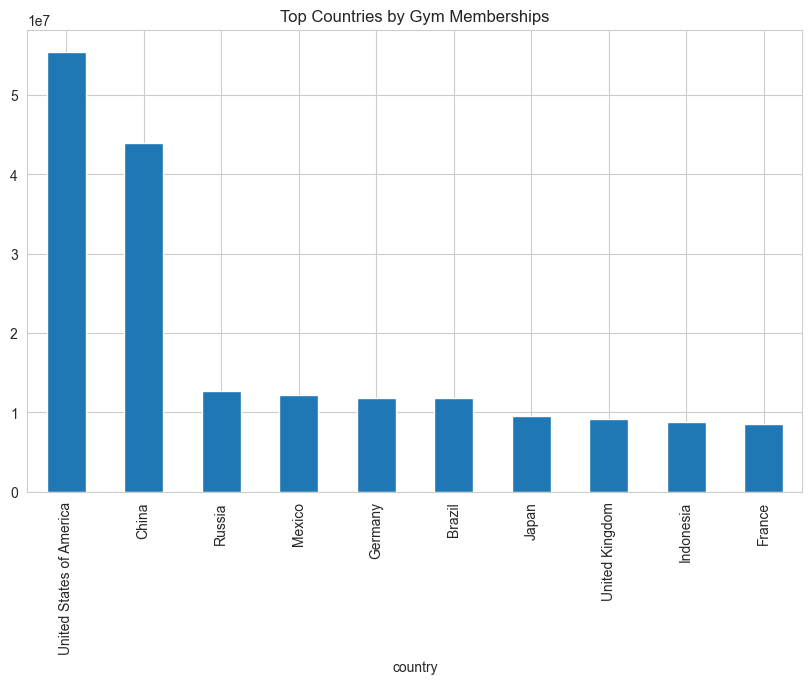

In [55]:
top = df.groupby("country")["gym_memberships"].mean().sort_values(ascending=False).head(10)

top.plot(kind="bar")
plt.title("Top Countries by Gym Memberships")
plt.show()

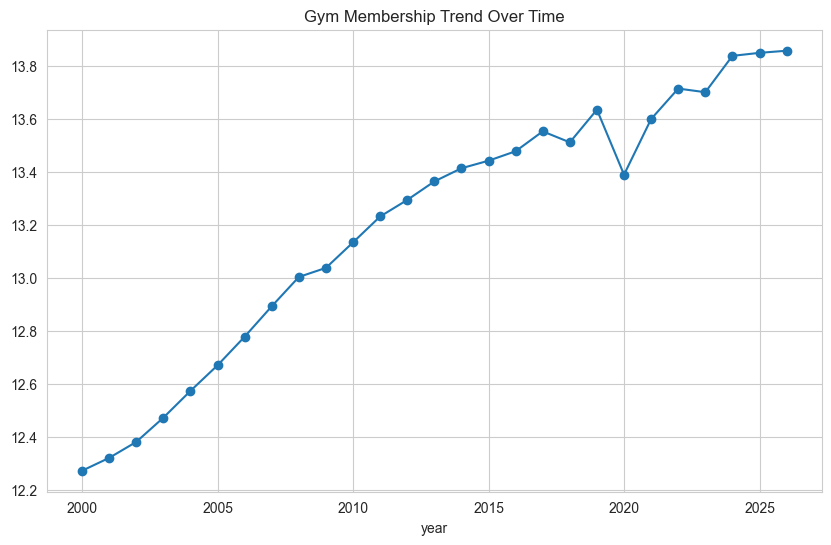

In [57]:
trend = df.groupby("year")["gym_memberships_log"].mean()

trend.plot(marker="o")
plt.title("Gym Membership Trend Over Time")
plt.show()